
--- Word Count Stats by fake_type ---
                  mean  median    std  min  max
fake_type                                      
generic_bot      35.12    33.0  21.84    2   95
negative_attack  25.39    12.5  32.89    3  180
neutral_bot      24.15    27.0  18.32    2  100
positive_spam    20.12    11.0  26.87    2  171

--- Word Count Stats by domain ---
                   mean  median    std  min  max
domain                                          
food              24.63    13.0  31.17    2  171
hotel             37.92    35.0  14.92    3   95
hotel_restaurant  16.83    10.0  27.14    2  156
product           19.84    10.0  31.86    2  180
products          29.49    31.0  12.70    2   53
services          19.28    10.0  25.72    2  174
transportation    19.80    11.0  25.00    2  177

--- Word Count Stats by language_style ---
                   mean  median    std  min  max
language_style                                  
code_mixed        32.01    16.0  41.17    3  180
engli

C:\Users\Acer\AppData\Local\Temp\ipykernel_14612\3448678981.py:31: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='fake_type', y='word_count', data=df, palette='viridis')


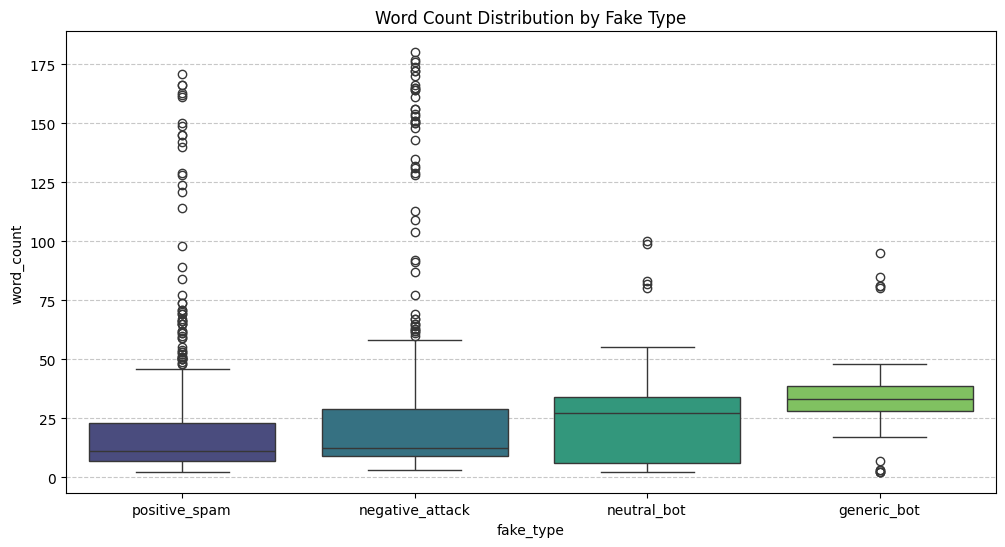

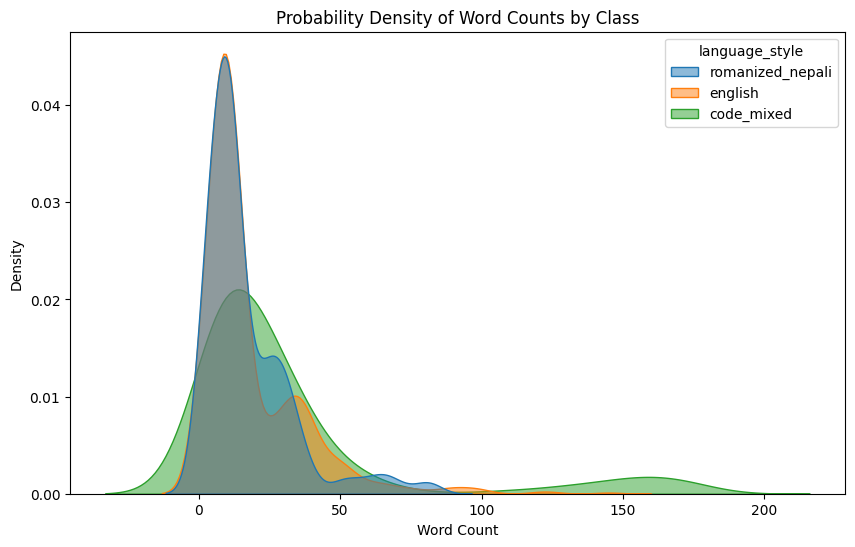

In [33]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import json

# 1. Load your dataset
# Replace 'your_data.json' with your actual filename
with open('data.json', 'r', encoding='utf-8') as f:
    data = json.load(f)

df = pd.DataFrame(data)

# 2. Calculate word count for each review
# Using a simple split; for more accuracy, use regex to handle punctuation
df['word_count'] = df['review_text'].apply(lambda x: len(str(x).split()))

# 3. Summary Statistics by Category
def get_stats(column):
    print(f"\n--- Word Count Stats by {column} ---")
    stats = df.groupby(column)['word_count'].agg(['mean', 'median', 'std', 'min', 'max']).round(2)
    print(stats)
    return stats

# Check stats for the most important categories
get_stats('fake_type')
get_stats('domain')
get_stats('language_style')

# 4. Visualization: Boxplots (Best for seeing outliers and bias)
plt.figure(figsize=(12, 6))
sns.boxplot(x='fake_type', y='word_count', data=df, palette='viridis')
plt.title('Word Count Distribution by Fake Type')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

# 5. Visualization: KDE Plot (Best for seeing the "Shape" of the data)
plt.figure(figsize=(10, 6))
sns.kdeplot(data=df, x='word_count', hue='language_style', fill=True, common_norm=False, alpha=0.5)
plt.title('Probability Density of Word Counts by Class')
plt.xlabel('Word Count')
plt.show()

In [23]:
df.language_style.value_counts()

language_style
english             652
code_mixed          462
romanized_nepali    456
Name: count, dtype: int64

In [3]:
def get_length_type(n):
    if n <= 10:
        return "very_short"      # 3–10 words (and shorter edge cases)
    elif n <= 25:
        return "short"           # 11–25
    elif n <= 60:
        return "medium"          # 26–60
    else:
        return "long"            # 60+

In [24]:
df.rating.value_counts()

rating
5    741
1    567
3    148
4     71
2     43
Name: count, dtype: int64

In [5]:
#count of rating =0
(df['rating'] == 0).sum()

np.int64(0)

In [25]:
df.domain.value_counts()

domain
services            324
food                318
transportation      296
product             250
hotel_restaurant    212
products             85
hotel                65
Name: count, dtype: int64

In [37]:
df["length_type"] = df["word_count"].apply(get_length_type)

length_type
very_short    42.698706
short         29.390018
medium        22.057917
long           5.853358
Name: proportion, dtype: float64


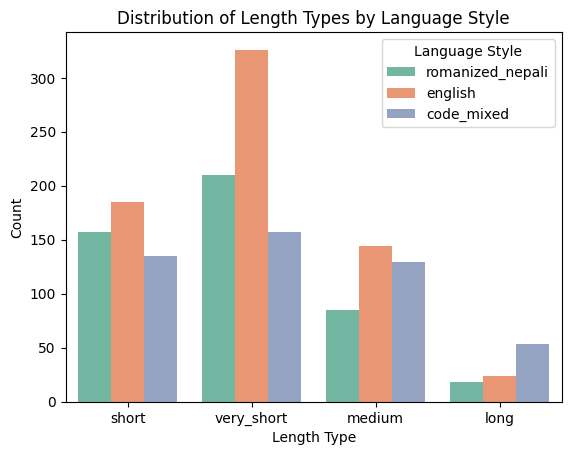

In [38]:
print(df["length_type"].value_counts(normalize=True) * 100)
sns.countplot(x='length_type', hue='language_style', data=df, palette='Set2')
plt.title('Distribution of Length Types by Language Style')
plt.xlabel('Length Type')
plt.ylabel('Count')
plt.legend(title='Language Style')
plt.show()

In [9]:
df1=pd.read_csv('dataset111.csv',encoding='utf-8')
df2=pd.read_csv('reviewdatapk.csv',encoding='utf-8')

In [10]:
df1['word_count'] = df1['review_text'].apply(lambda x: len(str(x).split()))
df2['word_count'] = df2['review_text'].apply(lambda x: len(str(x).split()))


--- Word Count Stats by domain ---
                  mean  median   std  min  max
domain                                        
food              7.60     7.0  1.76    4   16
hotel_restaurant  7.85     8.0  1.63    5   13
product           7.23     7.0  1.59    4   13
services          7.40     7.0  1.68    4   14
transportation    7.58     7.0  1.69    5   15

--- Word Count Stats by language_style ---
                  mean  median   std  min  max
language_style                                
code_mixed        7.41     7.0  1.56    4   15
english           7.84     8.0  1.95    4   16
romanized_nepali  7.32     7.0  1.42    4   12


C:\Users\Acer\AppData\Local\Temp\ipykernel_14612\2727409285.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='domain', y='word_count', data=df, palette='viridis')


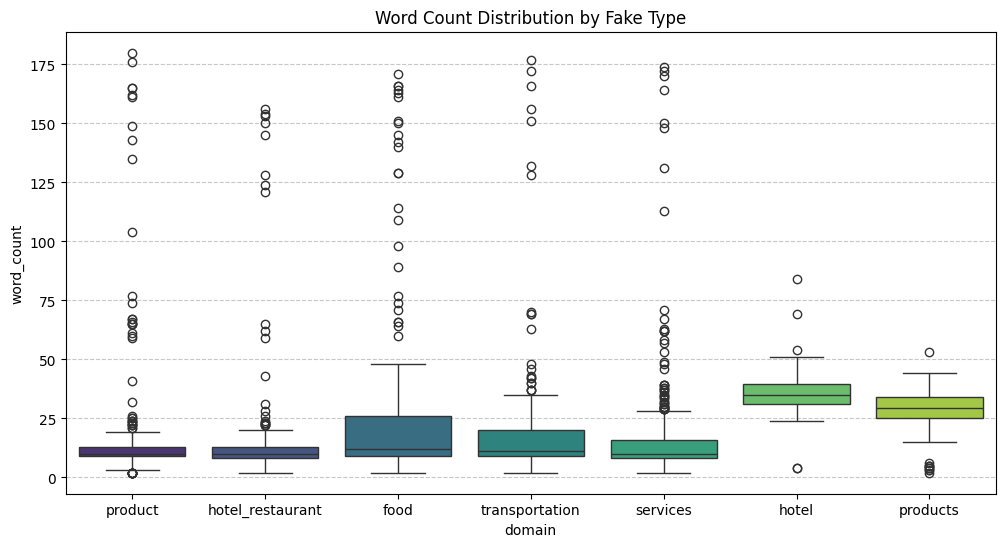

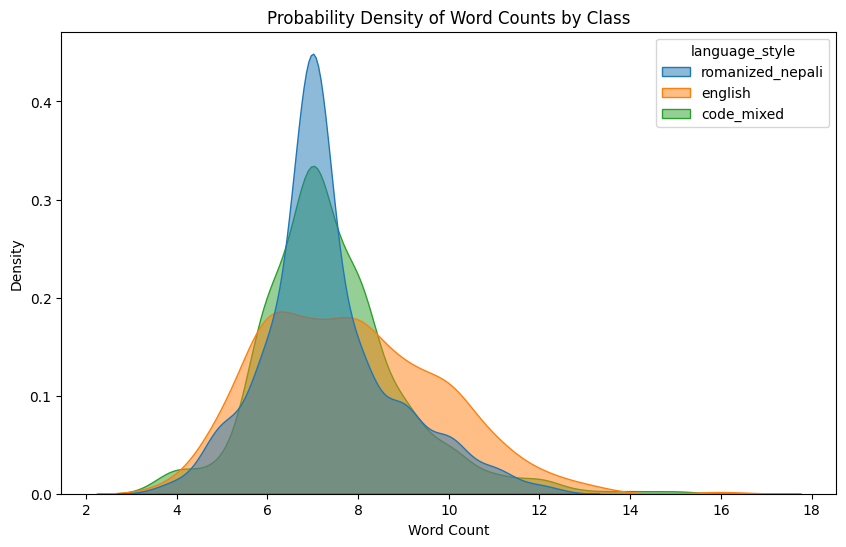

In [11]:
def get_stats(column):
    print(f"\n--- Word Count Stats by {column} ---")
    stats = df1.groupby(column)['word_count'].agg(['mean', 'median', 'std', 'min', 'max']).round(2)
    print(stats)
    return stats

# Check stats for the most important categories

get_stats('domain')
get_stats('language_style')

# 4. Visualization: Boxplots (Best for seeing outliers and bias)
plt.figure(figsize=(12, 6))
sns.boxplot(x='domain', y='word_count', data=df, palette='viridis')
plt.title('Word Count Distribution by Fake Type')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

# 5. Visualization: KDE Plot (Best for seeing the "Shape" of the data)
plt.figure(figsize=(10, 6))
sns.kdeplot(data=df1, x='word_count', hue='language_style', fill=True, common_norm=False, alpha=0.5)
plt.title('Probability Density of Word Counts by Class')
plt.xlabel('Word Count')
plt.show()

In [12]:
df1["length_type"] = df1["word_count"].apply(get_length_type)
print(df1["length_type"].value_counts(normalize=True) * 100)

length_type
very_short    94.336283
short          5.663717
Name: proportion, dtype: float64


In [13]:
df1.length_type.value_counts()

length_type
very_short    1066
short           64
Name: count, dtype: int64

In [14]:
df2["length_type"] = df2["word_count"].apply(get_length_type)
print(df2["length_type"].value_counts(normalize=True) * 100)
df2.length_type.value_counts()

length_type
very_short    96.663815
short          3.336185
Name: proportion, dtype: float64


length_type
very_short    1130
short           39
Name: count, dtype: int64

In [15]:
from collections import Counter

starters = (
    df1["review_text"]
      .dropna()
      .str.split()
      .str[0]
      .str.lower()
)

print("Top 5 Sentence Starters:", Counter(starters).most_common(10))
avg_words = df1["word_count"].mean()
print(f"Average word count: {avg_words:.2f}")

Top 5 Sentence Starters: [('bike', 44), ('hotel', 42), ('the', 39), ('scooter', 38), ('room', 31), ('driver', 30), ('momo', 24), ('service', 21), ('product', 19), ('cab', 19)]
Average word count: 7.53


In [16]:
starters = (
    df2["review_text"]
      .dropna()
      .str.split()
      .str[0]
      .str.lower()
)

print("Top 5 Sentence Starters:", Counter(starters).most_common(10))
avg_words = df2["word_count"].mean()
print(f"Average word count: {avg_words:.2f}")

Top 5 Sentence Starters: [('rider', 65), ('the', 50), ('stay', 48), ('hotel', 35), ('momo', 30), ('internet', 29), ('room', 28), ('bike', 26), ('scooter', 24), ('chicken', 23)]
Average word count: 7.54


In [32]:
df.describe()


,rating,has_slang,slang_count,word_count
count,1610.000000,1541.000000,1541.000000,1610.000000
mean,3.228571,0.310837,0.438676,21.287578
std,1.822770,0.462987,0.746183,26.839878
min,1.000000,0.000000,0.000000,2.000000
25%,1.000000,0.000000,0.000000,9.000000
50%,4.000000,0.000000,0.000000,11.000000
75%,5.000000,1.000000,1.000000,27.000000
max,5.000000,1.000000,4.000000,180.000000


In [35]:
import emoji
from collections import Counter

def audit_emojis(df, text_column='review_text', label_column='fake_type'):
    results = []
    
    for label in df[label_column].unique():
        subset = df[df[label_column] == label]
        all_text = " ".join(subset[text_column].astype(str))
        
        # Extract all emojis from the text
        emojis_found = [c for c in all_text if c in emoji.EMOJI_DATA]
        
        # Calculate Metrics
        total_emojis = len(emojis_found)
        unique_emojis = len(set(emojis_found))
        most_common = Counter(emojis_found).most_common(5)
        
        # Emoji Density: Total Emojis / Total Words in the class
        total_words = len(all_text.split())
        emoji_density = (total_emojis / total_words) if total_words > 0 else 0
        
        results.append({
            "Class": label,
            "Total Emojis": total_emojis,
            "Unique Variety": unique_emojis,
            "Density (per word)": round(emoji_density, 4),
            "Top 5 Emojis": most_common
        })
    
    return pd.DataFrame(results)



print(audit_emojis(df))

             Class  Total Emojis  Unique Variety  Density (per word)  \
0              NaN             0               0              0.0000   
1    positive_spam           161              30              0.0135   
2  negative_attack           142              13              0.0091   
3      neutral_bot            99              16              0.0218   
4      generic_bot            71              12              0.0470   

                                  Top 5 Emojis  
0                                           []  
1   [(⭐, 14), (✨, 12), (🔥, 9), (🏍, 9), (🍕, 8)]  
2  [(🔥, 41), (😡, 40), (‼, 32), (🍕, 8), (🛵, 6)]  
3   [(✨, 34), (⭐, 32), (🙏, 5), (🏨, 4), (🍕, 4)]  
4   [(✨, 28), (⭐, 19), (🙏, 9), (🏨, 4), (🛍, 3)]  


In [34]:


def audit_dataset_distribution(df, text_col='review_text', label_cols=['fake_type', 'language_style', 'domain']):
    """
    Analyzes word count distributions across different categories to find 'tells'.
    """
    # 1. Calculate word count for each entry
    df['word_count'] = df[text_col].apply(lambda x: len(str(x).split()))
    
    for col in label_cols:
        print(f"\n--- Word Count Stats by {col} ---")
        
        # Group by the category and calculate stats
        stats = df.groupby(col)['word_count'].agg(['mean', 'median', 'std', 'min', 'max']).round(2)
        
        # Calculate the 'Consistency Score' (Lower std means the class is too predictable)
        # Bots usually have a very low std (Standard Deviation)
        print(stats)
        
        # 2. Check for Statistical Outliers
        low_variance = stats[stats['std'] < 5.0]
        if not low_variance.empty:
            print(f"⚠️ WARNING: The following {col} classes have suspiciously low variance (Std < 5):")
            print(low_variance.index.tolist())

# --- Usage ---
# df = pd.read_json('your_dataset.json')
# audit_dataset_distribution(df)

# Mock Data to demonstrate the output


audit_dataset_distribution(df, label_cols=['fake_type'])


--- Word Count Stats by fake_type ---
                  mean  median    std  min  max
fake_type                                      
generic_bot      35.12    33.0  21.84    2   95
negative_attack  25.39    12.5  32.89    3  180
neutral_bot      24.15    27.0  18.32    2  100
positive_spam    20.12    11.0  26.87    2  171


In [40]:
def auditemojis(df, text_column='review_text', label_column='length_type'):
    results = []
    
    for label in df[label_column].unique():
        subset = df[df[label_column] == label]
        all_text = " ".join(subset[text_column].astype(str))
        
        # Extract all emojis from the text
        emojis_found = [c for c in all_text if c in emoji.EMOJI_DATA]
        
        # Calculate Metrics
        total_emojis = len(emojis_found)
        unique_emojis = len(set(emojis_found))
        most_common = Counter(emojis_found).most_common(5)
        
        # Emoji Density: Total Emojis / Total Words in the class
        total_words = len(all_text.split())
        emoji_density = (total_emojis / total_words) if total_words > 0 else 0
        
        results.append({
            "Class": label,
            "Total Emojis": total_emojis,
            "Unique Variety": unique_emojis,
            "Density (per word)": round(emoji_density, 4),
            "Top 5 Emojis": most_common
        })
    
    return pd.DataFrame(results)

In [41]:
print(auditemojis(df))

        Class  Total Emojis  Unique Variety  Density (per word)  \
0       short           176              31              0.0246   
1  very_short             9               4              0.0019   
2      medium           221              23              0.0173   
3        long            67              13              0.0063   

                                    Top 5 Emojis  
0    [(🔥, 17), (⭐, 13), (✨, 11), (🏍, 9), (🍕, 8)]  
1               [(✨, 6), (😡, 1), (⭐, 1), (🏨, 1)]  
2  [(✨, 41), (⭐, 41), (😡, 28), (🔥, 27), (‼, 19)]  
3     [(✨, 18), (⭐, 12), (🙏, 9), (‼, 6), (🔥, 6)]  
